# Week 4 — Chunking 전략 비교 실험

5 strategy를 같은 데이터(소수몽키 5건 transcript)·같은 retriever k=4·같은 chain·같은 metric(4개)으로 비교한다.

| 전략 | splitter | chunk_size | overlap | 비고 |
|---|---|---|---|---|
| A | RecursiveCharacterTextSplitter | 600 | 100 | baseline 재현, `separators=["\n\n", "\n", ". ", " ", ""]` |
| B-small | RecursiveCharacterTextSplitter | 500 | 100 | baseline과 같은 separators |
| B-large | RecursiveCharacterTextSplitter | 1500 | 300 | baseline과 같은 separators |
| C | RecursiveCharacterTextSplitter + 한국어 separators 보강 | 600 | 100 | `["다. ", "요. ", "습니다.", "다.", "요.", ". ", " ", ""]` |
| D | RecursiveCharacterTextSplitter + 한국어 separators 보강 | 1500 | 300 | B-large size + C separators 결합 (2x2 design) |

## 1. 회고 1번 자료 — 3주차 baseline retriever로 40 chunk 출력

기존 `study_naive_rag` collection을 그대로 사용해 10개 질문 × k=4 = 40 chunk를 출력. 사람 눈으로 훑어 "질문에 안 맞는 chunk"를 찾아 `docs/week4_retrospective.md` §1에 표로 정리한다 (LLM 호출 없음, 비용 0).

In [1]:
from naive_rag.constants import WEEK4_CONTENT_IDS, WEEK4_EVAL_DATA
from naive_rag.vectorstore import build_vectorstore

# study_naive_rag에는 4주차 시점 5건 외 추가 transcript가 들어있으므로
# 5건 화이트리스트로 metadata filter를 걸어 retrieve.
baseline_vs = build_vectorstore(collection_name="study_naive_rag")
baseline_retriever = baseline_vs.as_retriever(
    search_kwargs={
        "k": 4,
        "filter": {"content_id": {"$in": list(WEEK4_CONTENT_IDS)}},
    }
)
for i, d in enumerate(WEEK4_EVAL_DATA, 1):
    print(f"=== Q{i}: {d['question']} ===")
    chunks = baseline_retriever.invoke(d['question'])
    for j, c in enumerate(chunks):
        title = c.metadata.get("title", "?")
        pub = c.metadata.get("published_at", "?")
        preview = c.page_content[:160].replace("\n", " ")
        print(f"  [{j}] ({pub[:10]} | {title[:30]}) {preview}...")
    print()

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

=== Q1: 최근 AI 투자 전쟁에서 주목한 수혜주는 무엇인가? ===
  [0] (2026-04-28 | 빅테크 생존을 건 AI 투자 시작됐다,양보없는 전쟁의 ) 자, 이번 주 가장 중요한 이슈 있죠? 바로 슈퍼위크입니다. 빅테크 5개가 실적 발표합니다. 그래서 가장 최근 이슈들과 함께 또 주목할 만한 빅테크와 수예주들을 같이 정리 좀 해보도록 하겠습니다. 일단 제가 봤을 때는 이번 주 실적 발표를 예상하는 것보다 그냥 잘하고 있는 기업을 같이 ...
  [1] (2026-04-28 | 빅테크 생존을 건 AI 투자 시작됐다,양보없는 전쟁의 ) 올해 계속해서 엔트로픽 AI에이전트 붐에 연관되어있는 개인적으로는 아마존과 구글이 계속 주목해볼 만하고 만약에 실적발표에서 조금 미끄러진다면 저는 추가매수 대응할 계획으로 잡아놓은 상황이고 그리고 당연히 엔비디아는 뭐 말할것도 없죠 엔비디아도 1년 횡보디아 했거든요 엔비디아도 오른게 없...
  [2] (2025-10-04 | 미 증시 본격 버블은 아직 시작도 안했다? 2026 버) . 그러면 사실 확률이 높아집니다. 오, 엄청 좋은 팁이네요. 예를 들면 자료들도 준비해놨지만 최근에 각광받고 있는 테마 중에 네트워크 장비 쪽이 있어요. 아스테라랩스, 아이스탄 네트워크, 크레더 테크놀로지, 샘텍, 로맨턴 블링스 이런 종목들이 있는데 다 비슷비슷하게 AI 데터 센터를 ...
  [3] (2026-04-27 | AI에이전트가 반도체 판도 다 뒤집는다?새로운 주도주 ) . 그 외에도 제가 말씀드렸던 것처럼, 아마존의 자체 반도체, 구글의 자체 반도체, 퀄컴 등의 유명한 그런 테크 기업의 반도체, 대부분 ARM 설계한 ARM 기반의 반도체를 쓰기 때문에, 뒤에서 오는 또 하나의 수혜주로 볼 수 있겠죠? 그래서 저 같은 경우는 이 삼총사가 CPU 수혜주로...

=== Q2: AI 에이전트가 반도체 주도주 판도를 어떻게 바꾸고 있나? ===
  [0] (2026-04-27 | AI에이전트가 반도체 판도 다 뒤집는다?새로운 주도주

  [0] (2025-11-03 | 젠슨황의 깐부회동과 트럼프 순방이 끌어올린 증시, 주목) 아주 정리해보도록 하겠습니다. 자, 일단은 여기 그림 보시는 것처럼요. 오른쪽 그림 보시는 것처럼 정말 바쁜 한 주가 지나갔습니다. 에이팩 회담으로 각국의 정상들이 만났는데 다행히 좀 무사하게 잘 넘어간 것 같고 큰 이슈 없이겠죠? 오히려 증시 좀 불붙이는 이슈들도 많았고 빅테크 실적도...
  [1] (2025-11-03 | 젠슨황의 깐부회동과 트럼프 순방이 끌어올린 증시, 주목) . 제가 이제 결론적으로 우리 미국 주식 투자하는 입장에서 느꼈던 것은 트럼프의 쭉 행보를 보고 공통적으로 느낀 게 있습니다. 바로 요겁니다. 내가 돈 벌어왔다. 이겁니다. 이제 관점에 따라 다 다르게 생각하시겠지만 트럼프가 딱 아시아 APEC 순방 갔다 오고 나서 처음에 연 말이 내가...
  [2] (2026-04-27 | AI에이전트가 반도체 판도 다 뒤집는다?새로운 주도주 ) . 빅테크 실적 발표 시즌이 시작됩니다. 자, 그럼 트럼프 대통령도 바로 숟가락 얹는 거 확실하죠? 자, 이번 주에 미국 증시 올라가니까 오늘 주식시장은 사상 최고치를 기록했습니다. 솔직하게 말하자면, 미, 이란 전쟁 때문에 증시가 20에서 25% 하락할 거라고 생각했는데, 그것보다 영...
  [3] (2025-11-03 | 젠슨황의 깐부회동과 트럼프 순방이 끌어올린 증시, 주목) . 트럼프는 대통령이니까 그럴 수 있는데 저렇게 아시아 순방당해듯이 젠슨항도 한국에 번쩍, 번쩍, 지금도 대만 갔다가 영국 간다고 하거든요. 지금 젠슨항도 대만 TSMC 관계사도 만나러 가고 지금 영국도 AI 밀어줘야 돼가지고 젠슨항 지금 영국 간다고 하더라고요. 지금 바쁩니다. 진짜 ...

=== Q4: 2026 버블 시나리오에서 본격 버블은 시작됐다고 보나? ===
  [0] (2025-10-04 | 미 증시 본격 버블은 아직 시작도 안했다? 2026 버) . 알겠습니다. 제가 들었다가 말씀하신 거에 대해서 궁금한 게 우리가 

  [0] (2025-11-03 | 젠슨황의 깐부회동과 트럼프 순방이 끌어올린 증시, 주목) . 약간 가려졌는데 정말 곡괭이 파는 나중에 그냥 경제학 교과서 주식시장의 교과서를 그냥 엔비디아로 사례 분석을 그냥 딱 해놓는 게 아닐까 싶어요. 주식공부는 그냥 엔비디아 케이스를 딱 보면 될 것 같은데 정말 이 골드러시 금강의 시대가 걸리면 금을 캘 게 아니라 금을 캘기 위한 곡괭이...
  [1] (2026-04-28 | 빅테크 생존을 건 AI 투자 시작됐다,양보없는 전쟁의 ) 그냥 수직 계열을 하겠다고 발표했습니다 자 3가지인데요 일단 자체 반도체 자 이제 이건 앞에 영상에서 자세히 말씀드렸으니까 엔비디아에 의존도를 낮추기 위해서 자체 차세대 반도체 TPU 8세대를 발표하면서 엔비디아도 물론 하고 있습니다 오해하시면 안되는게 엔비디아 주문도 늘렸지만 자체 반...
  [2] (2026-04-28 | 빅테크 생존을 건 AI 투자 시작됐다,양보없는 전쟁의 ) 22년 말에 채집 PT가 본격적으로 풀리면서 그때부터 엔비디아 주가 랠리하고 시청 1등이 됐다고 해도 과언이 아닌 상황이기 때문에 젠수랑도 그걸 알기 때문에 오픈 AI가 잘 돼야 오픈 AI가 엔비디아에 반도체 많이 써주고 그래야 엔비디아도 계속 실적 유지가 되고 성장할 수 있기 때문에 ...
  [3] (2025-11-03 | 젠슨황의 깐부회동과 트럼프 순방이 끌어올린 증시, 주목) . 트럼프는 대통령이니까 그럴 수 있는데 저렇게 아시아 순방당해듯이 젠슨항도 한국에 번쩍, 번쩍, 지금도 대만 갔다가 영국 간다고 하거든요. 지금 젠슨항도 대만 TSMC 관계사도 만나러 가고 지금 영국도 AI 밀어줘야 돼가지고 젠슨항 지금 영국 간다고 하더라고요. 지금 바쁩니다. 진짜 ...

=== Q9: 2030년까지 컴퓨팅 용량 확장과 AI 인프라 전망은? ===
  [0] (2026-04-28 | 빅테크 생존을 건 AI 투자 시작됐다,양보없는 전쟁의 ) 이번에 보고서를 자체적으로 발표를 하면서 자 우리가 컴퓨팅 용량 2025

## 2. 4 strategy ingest

각 strategy를 별도 PGVector collection에 ingest. 기존 `study_naive_rag`는 건드리지 않는다.

In [2]:
from langchain_text_splitters import RecursiveCharacterTextSplitter
from naive_rag.constants import WEEK4_CONTENT_IDS
from naive_rag.loader import load_transcripts
from naive_rag.metadata import enrich_chunks

docs = load_transcripts(content_ids=WEEK4_CONTENT_IDS)
print(f"로드된 문서: {len(docs)}건")

_BASELINE_SEPARATORS = ["\n\n", "\n", ". ", " ", ""]
_KOREAN_SEPARATORS = ["다. ", "요. ", "습니다.", "다.", "요.", ". ", " ", ""]

def split_strategy_a(documents):
    splitter = RecursiveCharacterTextSplitter(
        chunk_size=600, chunk_overlap=100, separators=_BASELINE_SEPARATORS,
    )
    return enrich_chunks(splitter.split_documents(documents))

def split_strategy_b_small(documents):
    splitter = RecursiveCharacterTextSplitter(
        chunk_size=500, chunk_overlap=100, separators=_BASELINE_SEPARATORS,
    )
    return enrich_chunks(splitter.split_documents(documents))

def split_strategy_b_large(documents):
    splitter = RecursiveCharacterTextSplitter(
        chunk_size=1500, chunk_overlap=300, separators=_BASELINE_SEPARATORS,
    )
    return enrich_chunks(splitter.split_documents(documents))

def split_strategy_c(documents):
    splitter = RecursiveCharacterTextSplitter(
        chunk_size=600, chunk_overlap=100, separators=_KOREAN_SEPARATORS,
    )
    return enrich_chunks(splitter.split_documents(documents))

def split_strategy_d(documents):
    splitter = RecursiveCharacterTextSplitter(
        chunk_size=1500, chunk_overlap=300, separators=_KOREAN_SEPARATORS,
    )
    return enrich_chunks(splitter.split_documents(documents))

로드된 문서: 5건


In [3]:
from naive_rag.vectorstore import build_vectorstore

STRATEGIES = {
    "A":       ("study_week4_a",       split_strategy_a),
    "B-small": ("study_week4_b_small", split_strategy_b_small),
    "B-large": ("study_week4_b_large", split_strategy_b_large),
    "C":       ("study_week4_c",       split_strategy_c),
    "D":       ("study_week4_d",       split_strategy_d),
}

def ingest_strategy(name, collection_name, splitter_fn):
    chunks = splitter_fn(docs)
    vs = build_vectorstore(collection_name=collection_name)
    try:
        vs.delete_collection()
    except Exception as e:
        print(f"  (delete_collection 스킵: {e})")
    vs = build_vectorstore(collection_name=collection_name)
    vs.add_documents(chunks)
    return len(chunks)

chunk_counts = {}
for name, (coll, fn) in STRATEGIES.items():
    n = ingest_strategy(name, coll, fn)
    print(f"  {name:8s} -> collection '{coll}', chunks={n}")
    chunk_counts[name] = n

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

  A        -> collection 'study_week4_a', chunks=160


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

  C        -> collection 'study_week4_c', chunks=176


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

  D        -> collection 'study_week4_d', chunks=72


## 3. 메타데이터 7개 sanity check (과제 명세)

In [4]:
sample_vs = build_vectorstore(collection_name="study_week4_a")
sample = sample_vs.similarity_search("AI 투자", k=1)
print("Sample chunk metadata (전략 A):")
for k, v in sample[0].metadata.items():
    print(f"  {k}: {v}")
print()
print("Chunk preview:", sample[0].page_content[:200], "...")

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

Sample chunk metadata (전략 A):
  title: 빅테크 생존을 건 AI 투자 시작됐다,양보없는 전쟁의 수혜주들
  channel: 소수몽키
  content_id: 4c13f9f4-bb3e-4869-9536-ce3027ba9cbb
  chunk_index: 20
  chunk_total: 25
  published_at: 2026-04-28 00:00:00
  chunk_token_count: 596

Chunk preview: 사람 자르고 아니면 사람 대체하고 그 돈 맡겨서 AI 투자하는 거 이게 가속화 될 것 같아서 이게 마냥 웃으면서 할 수 있는 얘기는 아닌 것 같습니다 아무튼 지금 약간 딴 세상 얘기처럼 하고 있지만 무섭습니다 그래서 제가 한 번씩 말씀드리지만 지금 엄청난 변화의 순간이고 어느 순간 특이점이 오면 진짜 우리 생활에도 더 큰 영향을 줄 수 있기 때문에 저는 하 ...


## 4. 4 strategy 평가 (시간 좀 걸림, ~$0.01)

각 collection에 대해 `run_eval()`을 돌려 ragas 4 metric으로 평가.

In [5]:
from naive_rag.eval import run_eval

eval_results = {}
for name, (coll, _) in STRATEGIES.items():
    print(f"--- evaluating {name} ({coll}) ---")
    eval_results[name] = run_eval(collection_name=coll)
print("done")

--- evaluating A (study_week4_a) ---


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/40 [00:00<?, ?it/s]

...

LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.


LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.


LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.


LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.


done


## 5. 결과 표

In [6]:
import pandas as pd

_SIZE = {"A": 600, "B-small": 500, "B-large": 1500, "C": 600, "D": 1500}
_OVERLAP = {"A": 100, "B-small": 100, "B-large": 300, "C": 100, "D": 300}

METRIC_COLS = [
    "faithfulness",
    "answer_relevancy",
    "llm_context_precision_with_reference",
    "context_recall",
]

rows = []
for name, (coll, _) in STRATEGIES.items():
    df = eval_results[name].to_pandas()
    row = {
        "strategy": name,
        "chunk_size": _SIZE[name],
        "overlap": _OVERLAP[name],
        "chunk_count": chunk_counts[name],
    }
    for col in METRIC_COLS:
        if col in df.columns:
            row[col] = round(df[col].mean(), 4)
        else:
            row[col] = None
    rows.append(row)

summary = pd.DataFrame(rows)
summary

,strategy,chunk_size,overlap,chunk_count,faithfulness,answer_relevancy,llm_context_precision_with_reference,context_recall
0,A,600,100,160,0.9800,0.4671,0.9833,0.7250
1,B-small,500,100,196,0.8875,0.6223,1.0000,0.7167
2,B-large,1500,300,68,1.0000,0.6285,0.9444,0.9750
3,C,600,100,176,0.9250,0.6228,0.9917,0.8417
4,D,1500,300,72,0.9667,0.6178,0.9722,0.9500


## 5b. 상세 결과 — strategy × 질문별 response + retrieved chunks

각 strategy가 질문별로 어떤 chunk를 retrieve했고 어떤 답변을 만들었는지 펼쳐본다. eval cell이 만들어둔 `eval_results[name].to_pandas()`를 그대로 사용.

In [7]:
for name, (coll, _) in STRATEGIES.items():
    df = eval_results[name].to_pandas()
    print("\n" + "=" * 100)
    print(f"=== Strategy {name}  ({coll})")
    print("=" * 100)
    for i, row in df.iterrows():
        print(f"\n--- Q{i+1}: {row['user_input']} ---")
        resp = row['response']
        print(f"  [답변]\n  {resp[:600]}{'...' if len(resp) > 600 else ''}")
        print(f"  [Retrieved contexts (k={len(row['retrieved_contexts'])})]")
        for j, c in enumerate(row['retrieved_contexts']):
            preview = c[:200].replace('\n', ' ')
            print(f"    [{j}] {preview}...")


=== Strategy A  (study_week4_a)

--- Q1: 최근 AI 투자 전쟁에서 주목한 수혜주는 무엇인가? ---
  [답변]
  최근 AI 투자 전쟁에서 주목한 수혜주는 구글과 아마존입니다. 이 두 기업은 엔트로픽 AI에 대한 초기 투자를 통해 큰 평가 이익과 투자 수익을 기대하고 있으며, AI 인프라 붐의 열풍 속에서도 긍정적인 전망을 보이고 있습니다. 또한, 엔비디아도 AI 칩과 관련하여 하반기 기대감이 높아 주목받고 있습니다. 

[출처]
- 2026-04-28 빅테크 생존을 건 AI 투자 시작됐다,양보없는 전쟁의 수혜주들
  [Retrieved contexts (k=4)]
    [0] 자, 이번 주 가장 중요한 이슈 있죠? 바로 슈퍼위크입니다. 빅테크 5개가 실적 발표합니다. 그래서 가장 최근 이슈들과 함께 또 주목할 만한 빅테크와 수예주들을 같이 정리 좀 해보도록 하겠습니다. 일단 제가 봤을 때는 이번 주 실적 발표를 예상하는 것보다 그냥 잘하고 있는 기업을 같이 보는 게 중요할 것 같아요. 그래야 실적 발표 나와도 떨어지면 산다 이런...
    [1] 올해 계속해서 엔트로픽 AI에이전트 붐에 연관되어있는 개인적으로는 아마존과 구글이 계속 주목해볼 만하고 만약에 실적발표에서 조금 미끄러진다면 저는 추가매수 대응할 계획으로 잡아놓은 상황이고 그리고 당연히 엔비디아는 뭐 말할것도 없죠 엔비디아도 1년 횡보디아 했거든요 엔비디아도 오른게 없습니다 한번 펼쳐보세요 1년동안 쉬웠어요 한 번씩 빅테크가 횡보디아 뭐 ...
    [2] . 그러면 사실 확률이 높아집니다. 오, 엄청 좋은 팁이네요. 예를 들면 자료들도 준비해놨지만 최근에 각광받고 있는 테마 중에 네트워크 장비 쪽이 있어요. 아스테라랩스, 아이스탄 네트워크, 크레더 테크놀로지, 샘텍, 로맨턴 블링스 이런 종목들이 있는데 다 비슷비슷하게 AI 데터 센터를 연결해 놓고 여기서 네트워크나 이런 것들이 늘어나는 것을 수혜를 보는 기...
    [3] . 그 외에도 제가 말씀드렸던

## 6. chunk 분포 시각화

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

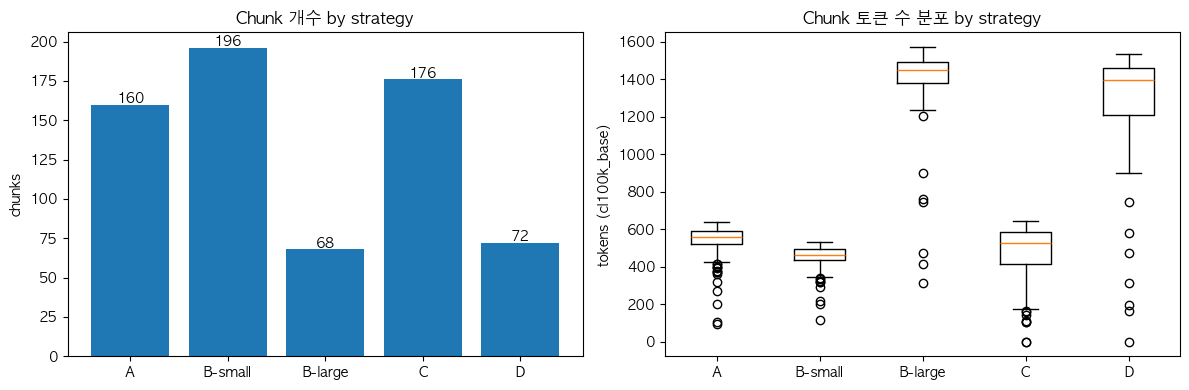

In [8]:
import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.rcParams["font.family"] = "AppleGothic"
mpl.rcParams["axes.unicode_minus"] = False

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# (1) strategy별 chunk_count
axes[0].bar(summary["strategy"], summary["chunk_count"])
axes[0].set_title("Chunk 개수 by strategy")
axes[0].set_ylabel("chunks")
for i, v in enumerate(summary["chunk_count"]):
    axes[0].text(i, v + 1, str(v), ha="center")

# (2) strategy별 chunk_token_count 분포 (boxplot)
data_for_box = []
labels = []
for name, (coll, _) in STRATEGIES.items():
    vs = build_vectorstore(collection_name=coll)
    # k를 chunk_count보다 크게 잡아 거의 모두 가져옴
    chunks = vs.similarity_search(" ", k=max(chunk_counts[name], 1))
    token_counts = [c.metadata.get("chunk_token_count", 0) for c in chunks]
    data_for_box.append(token_counts)
    labels.append(name)

axes[1].boxplot(data_for_box, tick_labels=labels)
axes[1].set_title("Chunk 토큰 수 분포 by strategy")
axes[1].set_ylabel("tokens (cl100k_base)")

plt.tight_layout()
plt.show()

## 다음 단계

- §1 (회고 1번 자료) 출력에서 잘못 retrieve된 chunk를 추려 `docs/week4_retrospective.md` §1 표로 옮긴다.
- §3 metadata sanity 결과 (7개 필드)는 한 단락으로 §5 메타데이터 활용 아이디어에 반영.
- §5 `summary` 표를 `docs/week4_retrospective.md` §4로 옮기고, §6 RAGAS 점수 해석 회고에 가설 작성.